In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("/content/test.csv")
df

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,5.018181,125.82,6.00,64.00,0.471037,0.471037,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.336227e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
1,0.000000,0.00,47.00,64.00,4.992473,4.992473,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.367746e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
2,0.000000,55.22,6.05,65.27,31.735421,31.735421,0.0,0.0,0.0,0.0,...,0.776120,55.82,8.306829e+07,9.5,10.409427,1.111579,30.890194,0.02,141.55,DDoS-TCP_Flood
3,0.008299,5213.00,17.00,64.00,19365.300906,19365.300906,0.0,0.0,0.0,0.0,...,0.000000,50.00,8.310303e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
4,4.672666,108.00,6.00,64.00,0.428021,0.428021,0.0,0.0,0.0,0.0,...,0.000000,54.00,8.295115e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-TCP_Flood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163223,0.000000,0.00,0.99,63.36,11.960863,11.960863,0.0,0.0,0.0,0.0,...,0.395549,42.18,8.348321e+07,9.5,9.176472,0.560754,1.756381,0.09,141.55,DDoS-ICMP_Flood
163224,3.101634,146.34,6.00,64.00,1.168902,1.168902,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.336554e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
163225,0.092433,30119.00,17.00,64.00,103050.369496,103050.369496,0.0,0.0,0.0,0.0,...,0.000000,50.00,8.309873e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
163226,0.000000,0.00,1.00,64.00,1.471917,1.471917,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.315007e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood


In [ ]:
df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,5.018181,125.82,6.00,64.00,0.471037,0.471037,0.0,0.0,1.0,0.0,...,0.00000,54.00,8.336227e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
1,0.000000,0.00,47.00,64.00,4.992473,4.992473,0.0,0.0,0.0,0.0,...,0.00000,592.00,8.367746e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
2,0.000000,55.22,6.05,65.27,31.735421,31.735421,0.0,0.0,0.0,0.0,...,0.77612,55.82,8.306829e+07,9.5,10.409427,1.111579,30.890194,0.02,141.55,DDoS-TCP_Flood
3,0.008299,5213.00,17.00,64.00,19365.300906,19365.300906,0.0,0.0,0.0,0.0,...,0.00000,50.00,8.310303e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
4,4.672666,108.00,6.00,64.00,0.428021,0.428021,0.0,0.0,0.0,0.0,...,0.00000,54.00,8.295115e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-TCP_Flood


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163228 entries, 0 to 163227
Data columns (total 47 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   flow_duration    163228 non-null  float64
 1   Header_Length    163228 non-null  float64
 2   Protocol Type    163228 non-null  float64
 3   Duration         163228 non-null  float64
 4   Rate             163228 non-null  float64
 5   Srate            163228 non-null  float64
 6   Drate            163227 non-null  float64
 7   fin_flag_number  163227 non-null  float64
 8   syn_flag_number  163227 non-null  float64
 9   rst_flag_number  163227 non-null  float64
 10  psh_flag_number  163227 non-null  float64
 11  ack_flag_number  163227 non-null  float64
 12  ece_flag_number  163227 non-null  float64
 13  cwr_flag_number  163227 non-null  float64
 14  ack_count        163227 non-null  float64
 15  syn_count        163227 non-null  float64
 16  fin_count        163227 non-null  floa

In [ ]:
df.describe()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,163228.000000,1.632280e+05,163228.000000,163228.000000,1.632280e+05,1.632280e+05,163227.000000,163227.000000,163227.000000,163227.000000,...,163227.000000,163227.000000,163227.000000,1.632270e+05,163227.000000,163227.000000,163227.000000,1.632270e+05,163227.000000,163227.000000
mean,6.082779,7.588075e+04,9.071709,66.348157,9.100646e+03,9.100646e+03,0.000001,0.086518,0.207821,0.090224,...,124.780803,33.267282,124.721873,8.320034e+07,9.499635,13.122728,47.009591,3.088543e+04,0.095751,141.540002
std,289.957242,4.599687e+05,8.948637,14.005845,1.025158e+05,1.025158e+05,0.000357,0.281128,0.405749,0.286503,...,242.439884,161.158761,242.517719,1.693950e+07,0.813365,8.640066,227.930790,3.574695e+05,0.232216,20.928300
min,0.000000,0.000000e+00,0.600000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,42.000000,0.000000,42.000000,1.072884e-06,1.000000,9.165151,0.000000,0.000000e+00,0.000000,1.000000
25%,0.000000,5.400000e+01,6.000000,64.000000,2.108214e+00,2.108214e+00,0.000000,0.000000,0.000000,0.000000,...,50.000000,0.000000,50.000000,8.307158e+07,9.500000,10.000000,0.000000,0.000000e+00,0.000000,141.550000
50%,0.000000,5.400000e+01,6.000000,64.000000,1.582505e+01,1.582505e+01,0.000000,0.000000,0.000000,0.000000,...,54.000000,0.000000,54.000000,8.312452e+07,9.500000,10.392305,0.000000,0.000000e+00,0.000000,141.550000
75%,0.103695,2.706900e+02,14.800000,64.000000,1.168285e+02,1.168285e+02,0.000000,0.000000,0.000000,0.000000,...,54.046126,0.357419,54.060000,8.334391e+07,9.500000,10.396455,0.505921,1.292410e+00,0.080000,141.550000
max,53539.500345,9.799668e+06,47.000000,255.000000,7.340032e+06,7.340032e+06,0.143006,1.000000,1.000000,1.000000,...,9231.150476,8290.916075,4257.200000,1.676394e+08,13.500000,128.612178,11725.125957,7.713750e+07,1.000000,244.600000


In [ ]:
df.shape

(163228, 47)

In [ ]:
df.isnull().sum()

,0
flow_duration,0
Header_Length,0
Protocol Type,0
Duration,0
Rate,0
Srate,0
Drate,1
fin_flag_number,1
syn_flag_number,1
rst_flag_number,1


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
flow_duration,0
Header_Length,0
Protocol Type,0
Duration,0
Rate,0
Srate,0
Drate,0
fin_flag_number,0
syn_flag_number,0
rst_flag_number,0


In [ ]:
df.duplicated().sum()

np.int64(122)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['label'].value_counts()

,count
label,
DDoS-ICMP_Flood,25144
DDoS-UDP_Flood,19044
DDoS-TCP_Flood,15682
DDoS-PSHACK_Flood,14245
DDoS-SYN_Flood,14245
DDoS-RSTFINFlood,14117
DDoS-SynonymousIP_Flood,12647
DoS-UDP_Flood,11578
DoS-TCP_Flood,9337


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['label'] = le.fit_transform(df['label'])

print(df['label'].head())

0    12
1    23
2    13
3    14
4    20
Name: label, dtype: int64


In [ ]:
df['label'].unique()

array([12, 23, 13, 14, 20, 18,  8,  9,  6, 21, 10, 24, 25, 19,  4, 17, 16,
        1, 26,  7, 29, 15, 22,  5, 32, 27, 33, 31,  2, 11, 30,  0,  3, 28])

In [ ]:
x = df.drop("label",axis = 1)
y = df["label"]

In [ ]:
print("Features:",x.shape)
print("Target:",y.shape)

Features: (163105, 46)
Target: (163105,)


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print("x_train:",x_train.shape)
print("x_test:",x_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

x_train: (130484, 46)
x_test: (32621, 46)
y_train: (130484,)
y_test: (32621,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
re = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
re.fit(x_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
y_pred = re.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred,average='weighted'))
print("Recall:",recall_score(y_test,y_pred,average='weighted'))
print("F1 Score:",f1_score(y_test,y_pred,average='weighted'))


Accuracy: 0.9901903681677447
Precision: 0.9897280855668642
Recall: 0.9901903681677447
F1 Score: 0.9893072693584856


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test,y_pred))
cm  = confusion_matrix(y_test,y_pred)
print(cm)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.82      0.99      0.90       788
           2       0.00      0.00      0.00         2
           3       1.00      0.33      0.50         3
           4       0.99      0.99      0.99       211
           5       1.00      0.83      0.90        23
           6       1.00      1.00      1.00      4912
           7       0.99      0.99      0.99       334
           8       1.00      1.00      1.00      2875
           9       1.00      1.00      1.00      2910
          10       1.00      1.00      1.00      2840
          11       0.60      0.92      0.73        13
          12       1.00      1.00      1.00      2571
          13       1.00      1.00      1.00      3151
          14       1.00      1.00      1.00      3736
          15       1.00      0.98      0.99       184
          16       0.80      0.61      0.69       137
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    learning_rate=0.1,
    max_depth=6
)
xgb.fit(x_train,y_train)
y_pred = xgb.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred,average='weighted'))
print("Recall:",recall_score(y_test,y_pred,average='weighted'))
print("F1 Score:",f1_score(y_test,y_pred,average='weighted'))

Accuracy: 0.9912632966493976
Precision: 0.9905004243915109
Recall: 0.9912632966493976
F1 Score: 0.9905861808170889


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test,y_pred))
cm  = confusion_matrix(y_test,y_pred)
print(cm)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.85      0.96      0.90       788
           2       0.00      0.00      0.00         2
           3       1.00      0.33      0.50         3
           4       1.00      1.00      1.00       211
           5       0.95      0.91      0.93        23
           6       1.00      1.00      1.00      4912
           7       1.00      1.00      1.00       334
           8       1.00      1.00      1.00      2875
           9       1.00      1.00      1.00      2910
          10       1.00      1.00      1.00      2840
          11       0.85      0.85      0.85        13
          12       1.00      1.00      1.00      2571
          13       1.00      1.00      1.00      3151
          14       1.00      1.00      1.00      3736
          15       0.99      0.99      0.99       184
          16       0.71      0.56      0.63       137
          17       0.75    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


            Feature  Importance
7   fin_flag_number    0.413260
10  psh_flag_number    0.216401
30             ICMP    0.148408
8   syn_flag_number    0.058955
39              IAT    0.033532
2     Protocol Type    0.033142
27              UDP    0.022533
45           Weight    0.019786
18        rst_count    0.011028
4              Rate    0.008566


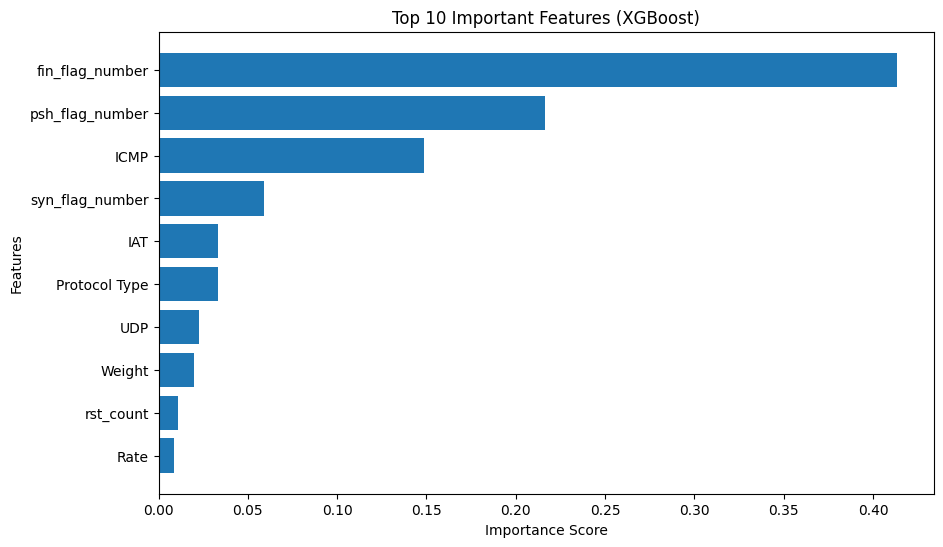

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'][:10],
         feature_importance['Importance'][:10])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features (XGBoost)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import joblib
joblib.dump(xgb,"xgb_model.pkl")
print("Model saved")

Model saved


In [ ]:
loaded_model = joblib.load("xgb_model.pkl")
PredictionErrorDisplay = loaded_model.predict(x_test[:5])
print("predictions:", PredictionErrorDisplay)
print("actual:",x_test[:5])

predictions: [13 14 12  8  9]
actual:         flow_duration  Header_Length  Protocol Type  Duration          Rate  \
96451         0.00029          54.86           6.00     64.59     73.544758   
25027         0.01661       13324.50          17.00     64.00  18720.001869   
141310        0.00000          54.00           6.00     64.00     29.697411   
140378        0.00000          54.39           6.11     64.00      3.808160   
114271        0.00000          54.00           6.00     64.00     12.219332   

               Srate  Drate  fin_flag_number  syn_flag_number  \
96451      73.544758    0.0              0.0              0.0   
25027   18720.001869    0.0              0.0              0.0   
141310     29.697411    0.0              0.0              1.0   
140378      3.808160    0.0              0.0              0.0   
114271     12.219332    0.0              1.0              0.0   

        rst_flag_number  ...        AVG       Std  Tot size           IAT  \
96451              

In [ ]:
import joblib
joblib.dump(le,"label_encoder.pkl")
print("label_encoder saved")

label_encoder saved


In [ ]:
sample = x.iloc[[0]]
print("Sample Data:")
print(sample)

Sample Data:
   flow_duration  Header_Length  Protocol Type  Duration      Rate     Srate  \
0       5.018181         125.82            6.0      64.0  0.471037  0.471037   

   Drate  fin_flag_number  syn_flag_number  rst_flag_number  ...   AVG  Std  \
0    0.0              0.0              1.0              0.0  ...  54.0  0.0   

   Tot size           IAT  Number   Magnitue  Radius  Covariance  Variance  \
0      54.0  8.336227e+07     9.5  10.392305     0.0         0.0       0.0   

   Weight  
0  141.55  

[1 rows x 46 columns]


In [ ]:
model = joblib.load("xgb_model.pkl")
label_encoder = joblib.load("label_encoder.pkl")

In [ ]:
prediction = model.predict(sample)
print("Prediction Label:",prediction)

attck_name = label_encoder.inverse_transform(prediction)
print("Attack Name:",attck_name)

Prediction Label: [12]
Attack Name: ['DDoS-SynonymousIP_Flood']


In [ ]:
actual_label = y.iloc[0]
print("Actual Label:",actual_label)

Actual Label: 12


In [ ]:
actual_Attack = label_encoder.inverse_transform([int(actual_label)])
print("Actual Attack:",actual_Attack)

Actual Attack: ['DDoS-SynonymousIP_Flood']


In [ ]:
def predict_attack(sample):
  prediction = model.predict(sample)
  attack = label_encoder.inverse_transform(prediction)
  print("Prediction attack:",attack[0])
  return attack[0]

In [ ]:
predict_attack(sample)

Prediction attack: DDoS-SynonymousIP_Flood


'DDoS-SynonymousIP_Flood'

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 48.4 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the model and label encoder
model = joblib.load("RCD_XGBoost_Model.pkl") # Corrected filename
label_encoder = joblib.load("label_encoder.pkl")

st.set_page_config(page_title="AIShield", layout="wide")

st.title("🛡️ AIShield")
st.subheader("AI-Driven Cyber Attack Detection for Smart Healthcare")

st.write("Enter the 46 feature values to predict the attack.")

# Define the 46 features based on your x_train columns or similar structure
# You can get these from x.columns if x is still available in the kernel state
features = [
    "flow_duration", "Header_Length", "Protocol Type", "Duration", "Rate",
    "Srate", "Drate", "fin_flag_number", "syn_flag_number", "rst_flag_number",
    "psh_flag_number", "ack_flag_number", "ece_flag_number", "cwr_flag_number",
    "ack_count", "syn_count", "fin_count", "urg_count", "rst_count",
    "HTTP", "HTTPS", "DNS", "Telnet", "SMTP", "SSH", "IRC", "TCP", "UDP",
    "DHCP", "ARP", "ICMP", "IPv", "LLC", "Tot sum", "Min", "Max", "AVG",
    "Std", "Tot size", "IAT", "Number", "Magnitue", "Radius", "Covariance",
    "Variance", "Weight"
]

input_data = {}

st.sidebar.header("Input Features")

# Create input fields for each feature
for feature in features:
    input_data[feature] = st.sidebar.number_input(f"Enter {feature}", value=0.0)

# Convert input data to DataFrame
input_df = pd.DataFrame([input_data])

st.write("### Your Input Features:")
st.write(input_df)

if st.button("Predict Attack Type"):
    try:
        # Make prediction
        prediction_label = model.predict(input_df)
        attack_name = label_encoder.inverse_transform(prediction_label)

        st.success(f"The predicted cyber attack type is: **{attack_name[0]}**")
    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.warning("Please ensure all 46 features are correctly entered.")

Writing app.py


%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model and label encoder
model = joblib.load("xgboost_model.pkl")
label_encoder = joblib.load("label_encoder.pkl")

st.set_page_config(page_title="AIShield", layout="wide")

st.title("🛡️ AIShield")
st.subheader("AI-Driven Cyber Attack Detection for Smart Healthcare")

st.write("Enter feature values below:")

# Feature names
features = [
    "flow_duration",
    "Header_Length",
    "Protocol Type",
    "Duration",
    "Rate",
    "Srate",
    "Drate",
    "fin_flag_number",
    "syn_flag_number",
    "rst_flag_number",
    "psh_flag_number",
    "ack_flag_number",
    "ece_flag_number",
    "cwr_flag_number",
    "ack_count",
    "syn_count",
    "fin_count",
    "urg_count",
    "rst_count",
    "HTTP",
    "HTTPS",
    "DNS",
    "Telnet",
    "SMTP",
    "SSH",
    "IRC",
    "TCP",
    "UDP",
    "DHCP",
    "ARP",
    "ICMP",
    "IPv",
    "LLC",
    "Tot sum",
    "Min",
    "Max",
    "AVG",
    "Std",
    "Tot size",
    "IAT",
    "Number",
    "Magnitude",
    "Radius",
    "Covariance",
    "Variance",
    "Weight"
]

inputs = []

for feature in features:
    value = st.number_input(feature, value=0.0)
    inputs.append(value)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

df = pd.read_csv("/content/test.csv")
df = df.dropna()
df = df.drop_duplicates()

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

x = df.drop("label",axis = 1)
y = df["label"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nFull Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9922168017975685
Precision: 0.9915807531467218
Recall: 0.9922168017975685
F1 Score: 0.9915956580748505

Full Report:



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.86      0.97      0.91      5572
           2       0.25      0.05      0.09        19
           3       1.00      0.17      0.29        18
           4       1.00      1.00      1.00      1457
           5       0.99      0.95      0.97       129
           6       1.00      1.00      1.00     35969
           7       1.00      1.00      1.00      2235
           8       1.00      1.00      1.00     20522
           9       1.00      1.00      1.00     20315
          10       1.00      1.00      1.00     20084
          11       0.92      0.97      0.95       110
          12       1.00      1.00      1.00     18024
          13       1.00      1.00      1.00     22768
          14       1.00      1.00      1.00     27076
          15       1.00      1.00      1.00      1499
          16       0.69      0.64      0.66       853
          17       0.70    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


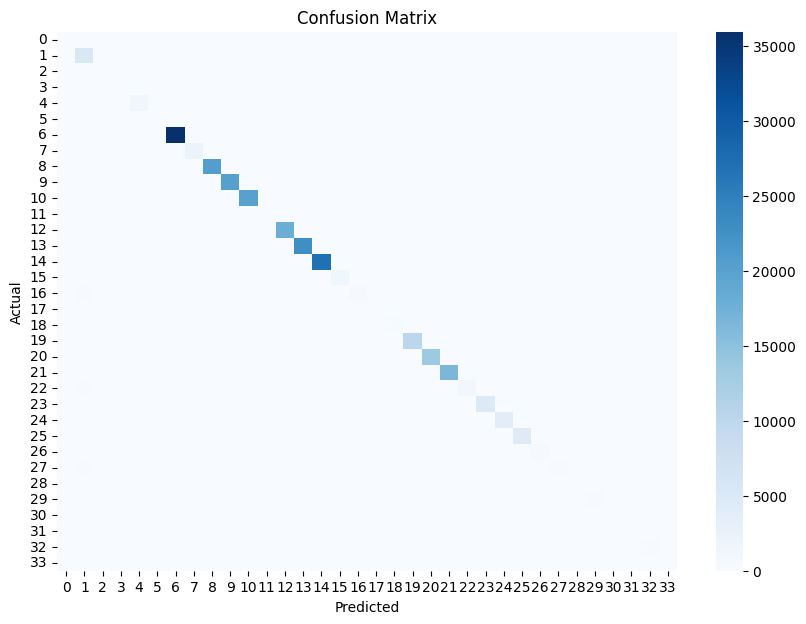

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

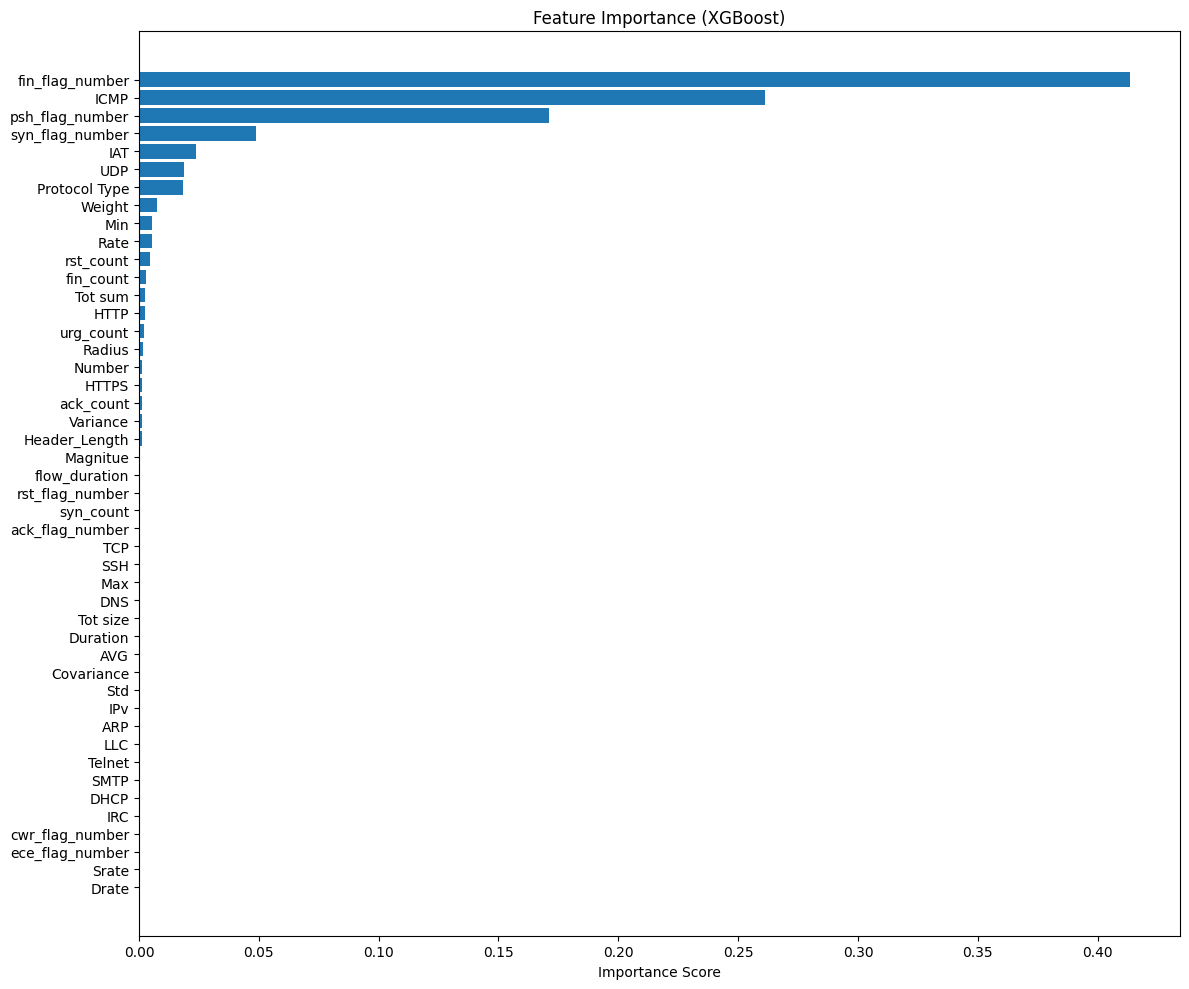

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance
importances = xgb.feature_importances_
features = x.columns

# Sort them
indices = importances.argsort()

plt.figure(figsize=(12, 10))  # increase size

plt.barh(range(len(indices)), importances[indices])

plt.yticks(range(len(indices)), [features[i] for i in indices])

plt.xlabel("Importance Score")
plt.title("Feature Importance (XGBoost)")

plt.tight_layout()  # VERY IMPORTANT FIX
plt.show()

In [ ]:
import joblib

joblib.dump(xgb, "RCD_XGBoost_Model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
#creating OIR

In [ ]:
def smart_oir(attack):
    severity = "Low"
    action = "Monitor and Log Activity"

    if "DDoS" in attack or "DoS" in attack:
        severity = "High"
        action = "Block IP, Enable Rate Limiting, Alert Admin"
    elif "SQL" in attack or "CommandInjection" in attack or "XSS" in attack or "Uploading_Attack" in attack or "VulnerabilityScan" in attack or "DictionaryBruteForce" in attack:
        severity = "Critical"
        action = "Isolate System, Log Incident, Alert Security Team, Patch Vulnerability"
    elif "Phishing" in attack or "BrowserHijacking" in attack:
        severity = "Medium"
        action = "Block URL, Notify User, Update Firewall Rules, Conduct User Training"
    elif "Mirai" in attack:
        severity = "High"
        action = "Isolate Device, Scan for Malware, Update Firmware, Alert Admin"
    elif "Recon" in attack:
        severity = "Low"
        action = "Increase Monitoring, Review Logs, Block Suspicious IPs"
    elif "Benign" in attack:
        severity = "None"
        action = "Allow Traffic"
    elif "MITM" in attack or "DNS_Spoofing" in attack:
        severity = "High"
        action = "Check Network Configuration, Isolate Affected Devices, Update Security Protocols"
    elif "Backdoor_Malware" in attack:
        severity = "Critical"
        action = "Isolate System, Eradicate Malware, Forensic Analysis, Rebuild System"

    return severity, action

In [ ]:
import joblib

# Ensure label_encoder is loaded if not already in memory
if 'label_encoder' not in locals() or label_encoder is None:
    label_encoder = joblib.load("label_encoder.pkl")

# Ensure xgb is loaded if not already in memory
if 'xgb' not in locals() or xgb is None:
    xgb = joblib.load("xgb_model.pkl") # Assuming xgb_model.pkl contains the trained XGBoost model

sample_pred = xgb.predict(x_test.iloc[[0]])
attack = label_encoder.inverse_transform(sample_pred)[0]

# Assuming incident_response_system should be smart_oir
# smart_oir returns severity and action
severity, action = smart_oir(attack)

print("Predicted Attack:", attack)
print("Recommended Action:", action)

Predicted Attack: DoS-SYN_Flood
Recommended Action: Block IP, Enable Rate Limiting, Alert Admin


In [ ]:
x_test.iloc[[0]]

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
936384,0.0,54.0,6.0,64.0,12.001488,12.001488,0.0,0.0,1.0,0.0,...,54.0,0.0,54.0,8.298595e+07,9.5,10.392305,0.0,0.0,0.0,141.55


In [ ]:
for i in range(5):
    sample_pred = xgb.predict(x_test.iloc[[i]])
    attack = label_encoder.inverse_transform(sample_pred)[0]
    # Correctly call smart_oir and assign its two return values
    severity, action = smart_oir(attack)

    print("\nSample:", i)
    print("Predicted Attack:", attack)
    print("Severity:", severity)
    print("Recommended Action:", action)


Sample: 0
Predicted Attack: DoS-SYN_Flood
Severity: High
Recommended Action: Block IP, Enable Rate Limiting, Alert Admin

Sample: 1
Predicted Attack: DDoS-RSTFINFlood
Severity: High
Recommended Action: Block IP, Enable Rate Limiting, Alert Admin

Sample: 2
Predicted Attack: DDoS-ICMP_Flood
Severity: High
Recommended Action: Block IP, Enable Rate Limiting, Alert Admin

Sample: 3
Predicted Attack: DDoS-PSHACK_Flood
Severity: High
Recommended Action: Block IP, Enable Rate Limiting, Alert Admin

Sample: 4
Predicted Attack: Mirai-greip_flood
Severity: High
Recommended Action: Isolate Device, Scan for Malware, Update Firmware, Alert Admin


In [ ]:
def AIShield_predict(sample):
    pred = xgb.predict(sample)
    attack = label_encoder.inverse_transform(pred)[0]
    severity, action = smart_oir(attack)

    return {
        "Attack": attack,
        "Severity": severity,
        "Action": action
    }

In [ ]:
result = AIShield_predict(x_test.iloc[[0]])
print(result)

{'Attack': 'DoS-SYN_Flood', 'Severity': 'High', 'Action': 'Block IP, Enable Rate Limiting, Alert Admin'}


In [ ]:
import joblib

joblib.dump(xgb, "AIShield_RCD_Model.pkl")
joblib.dump(label_encoder, "AIShield_LabelEncoder.pkl")

['AIShield_LabelEncoder.pkl']

In [ ]:
from sklearn.metrics import classification_report

y_pred = xgb.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.86      0.97      0.91      5572
           2       0.25      0.05      0.09        19
           3       1.00      0.17      0.29        18
           4       1.00      1.00      1.00      1457
           5       0.99      0.95      0.97       129
           6       1.00      1.00      1.00     35969
           7       1.00      1.00      1.00      2235
           8       1.00      1.00      1.00     20522
           9       1.00      1.00      1.00     20315
          10       1.00      1.00      1.00     20084
          11       0.92      0.97      0.95       110
          12       1.00      1.00      1.00     18024
          13       1.00      1.00      1.00     22768
          14       1.00      1.00      1.00     27076
          15       1.00      1.00      1.00      1499
          16       0.69      0.64      0.66       853
          17       0.70    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone # Import clone

# Load the xgb model if not already defined
if 'xgb' not in locals() or xgb is None:
    xgb = joblib.load('xgb_model.pkl')

# --- Ensure x and y are defined --- #
# Load data if not already present
if 'df' not in locals():
    df = pd.read_csv("/content/test.csv")
    df = df.dropna()
    df = df.drop_duplicates()

# Initialize LabelEncoder if not already present or load it if saved
if 'le' not in locals() or le is None:
    try:
        le = joblib.load("label_encoder.pkl")
    except FileNotFoundError:
        le = LabelEncoder()
        df['label'] = le.fit_transform(df['label'])
    else:
        # If loaded, transform 'label' using the loaded encoder
        # Ensure the 'label' column exists before transforming
        if 'label' in df.columns:
            df['label'] = le.transform(df['label'])

# Define x and y
x = df.drop("label", axis=1)
y = df["label"]
# --- End of x and y definition --- #

# Determine the number of unique classes from the LabelEncoder
num_classes = len(le.classes_)

# Create a clone of the loaded/existing xgb model and set num_class
# This ensures the cross_val_score uses an xgb that expects all classes
xgb_cv = clone(xgb)
xgb_cv.set_params(num_class=num_classes)

# Take a sample of the dataset for faster cross-validation
X_sample = x.sample(n=50000, random_state=42)
y_sample = y.loc[X_sample.index]

scores = cross_val_score(
    xgb_cv, # Use the cloned model with num_class set
    X_sample,
    y_sample,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Cross Validation Scores: [0.988     nan 0.9892 0.9906 0.9894]
Average Accuracy: nan
Standard Deviation: nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 553, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1762, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expect

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.model_selection import train_test_split

# Ensure x, y are defined (assuming they are in kernel from previous cells)
# x and y should be available from earlier data processing cells.

# Re-split data to get y_test (consistent with previous splits)
_, x_test, _, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Re-predict to get y_pred (assuming xgb model is loaded in kernel)
# xgb model should be available from earlier training or loading cells.
# If xgb is not in scope, uncomment the line below to load it:
# import joblib
# xgb = joblib.load('RCD_XGBoost_Model.pkl') # or 'xgb_model.pkl' based on your save name
y_pred = xgb.predict(x_test)

print("AIShield FINAL EVL SUMMARY")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))

AIShield FINAL EVL SUMMARY
Accuracy: 0.9916871000538245
F1 Score: 0.9911455717326795
Recall: 0.9916871000538245


Network Traffic Data
        ↓
RCD (XGBoost Model)
        ↓
Attack Classification
        ↓
OIR (Response System)
        ↓
EVL (Validation Layer)
        ↓
Final AIShield Output

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("="*50)
print("        AIShield - FINAL EVL SUMMARY")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

print("="*50)
print("AIShield Framework Evaluation Completed Successfully.")
print("="*50)

        AIShield - FINAL EVL SUMMARY
Accuracy : 99.17%
Precision: 99.11%
Recall   : 99.17%
F1 Score : 99.11%
AIShield Framework Evaluation Completed Successfully.
